# Практическая работа № 1. PyTorch
## Вариант 12 — BatchNorm и динамика обучения

## 1. Подготовка окружения

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Matplotlib is building the font cache; this may take a moment.


PyTorch: 2.14.0
CUDA available: False
Device: cpu


PyTorch 2.14.0. Устройство: CPU. CUDA недоступна.

> Почему наличие GPU ещё не означает, что программа автоматически начнёт выполнять вычисления на GPU?

GPU нужно явно выбрать: модель и данные переносятся на него через `.to(device)`.

## 2. Работа с тензорами

In [2]:
x = torch.tensor([[1., 2., 3.], [4., 5., 6.]])
print(x)
print(x.shape, x.dtype, x.device, x.ndim)
print("mean:", x.mean(), "std:", x.std(), "sum:", x.sum(), "max:", x.max())

torch.manual_seed(42)
x = torch.randn(64, 128)
print("64 × 128:", x.mean().item(), x.std().item(), x.min().item(), x.max().item())

A = torch.randn(128, 256)
B = torch.randn(256, 64)
C = A @ B
print("A @ B:", C.shape)

tensor([[1., 2., 3.],
        [4., 5., 6.]])
torch.Size([2, 3]) torch.float32 cpu 2
mean: tensor(3.5000) std: tensor(1.8708) sum: tensor(21.) max: tensor(6.)
64 × 128: 0.006507170386612415 1.0003782510757446 -3.832531690597534 3.4456253051757812
A @ B: torch.Size([128, 64])


Форма произведения — 128 × 64: внутренние размерности матриц совпадают.

## 3. CPU и GPU

In [3]:
import time

A, B = A.to(device), B.to(device)
print("Устройство результата:", (A @ B).device)

A, B = torch.randn(3000, 3000), torch.randn(3000, 3000)
start = time.perf_counter()
C = A @ B
print("CPU, с:", time.perf_counter() - start)

if torch.cuda.is_available():
    A, B = A.to("cuda"), B.to("cuda")
    torch.cuda.synchronize()
    start = time.perf_counter()
    C = A @ B
    torch.cuda.synchronize()
    print("GPU, с:", time.perf_counter() - start)

Устройство результата: cpu
CPU, с: 0.023960249964147806


> Почему для маленьких тензоров GPU иногда может оказаться медленнее CPU?

На маленьких тензорах затраты на передачу данных и запуск GPU могут превышать время самих вычислений. Без CUDA сравнение недоступно.

## 4–5. Autograd и численная производная

Для $f(x)=(x^2+3x)\sin x$:
$$f'(x)=(2x+3)\sin x+(x^2+3x)\cos x.$$

In [4]:
import pandas as pd

def f(x):
    return (x ** 2 + 3 * x) * torch.sin(x)

rows = []
for value in [2., -2., -1., 0.5, 4.]:
    x = torch.tensor(value, dtype=torch.float64, requires_grad=True)
    f(x).backward()
    eps = 1e-5
    numerical = (f(x.detach() + eps) - f(x.detach() - eps)) / (2 * eps)
    rows.append([value, x.grad.item(), numerical.item(), abs(x.grad.item() - numerical.item())])

pd.DataFrame(rows, columns=["x", "autograd", "численная", "модуль разности"])

,x,autograd,численная,модуль разности
0,2.0,2.203614,2.203614,2.434550e-10
1,-2.0,1.741591,1.741591,1.401845e-10
2,-1.0,-1.922076,-1.922076,1.164124e-10
3,0.5,3.453472,3.453472,4.279421e-11
4,4.0,-26.626849,-26.626849,9.781793e-10


> Почему эти значения не обязаны совпадать абсолютно точно?

Производные совпали с точностью до округления. Численная разность приближённая; при слишком малом шаге растёт ошибка вычитания близких чисел.

## 6–7. Генерация и визуализация данных

torch.Size([3000, 2]) torch.Size([3000])


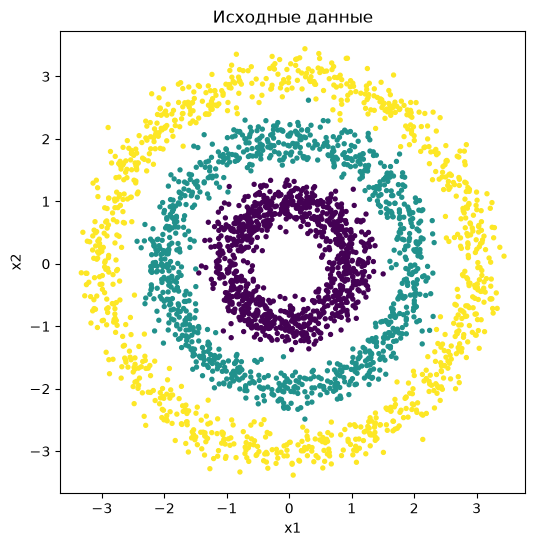

In [5]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

def generate_ring(n, radius, noise, label):
    angle = torch.rand(n) * 2 * torch.pi
    r = radius + noise * torch.randn(n)
    X = torch.stack([r * torch.cos(angle), r * torch.sin(angle)], dim=1)
    y = torch.full((n,), label, dtype=torch.long)
    return X, y

X0, y0 = generate_ring(1000, 1., 0.18, 0)
X1, y1 = generate_ring(1000, 2., 0.18, 1)
X2, y2 = generate_ring(1000, 3., 0.18, 2)
X = torch.cat([X0, X1, X2])
y = torch.cat([y0, y1, y2])
print(X.shape, y.shape)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=8)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Исходные данные")
plt.axis("equal")
plt.show()

> Почему обычный линейный классификатор не сможет идеально решить данную задачу?

Линейный классификатор разделяет классы прямыми. Здесь нужны замкнутые границы вокруг колец.

## 8–9. Разбиение и нормализация

In [6]:
indices = torch.randperm(len(X))
train_idx, val_idx, test_idx = indices[:2100], indices[2100:2550], indices[2550:]
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

mean = X_train.mean(dim=0)
std = X_train.std(dim=0)
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

print("Размеры:", len(X_train), len(X_val), len(X_test))
print("Среднее train:", X_train.mean(0))
print("Std train:", X_train.std(0))

Размеры: 2100 450 450
Среднее train: tensor([ 1.8165e-09, -3.8601e-09])
Std train: tensor([1., 1.])


Получено 2100/450/450 объектов.

> Почему нельзя сначала нормализовать весь набор данных, а потом разделять его на train, validation и test?

Mean и std считаются только по train, иначе в подготовку данных попадёт информация из validation и test.

## 10–11. Dataset и DataLoader

In [7]:
class ClassificationDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

train_dataset = ClassificationDataset(X_train, y_train)
val_dataset = ClassificationDataset(X_val, y_val)
test_dataset = ClassificationDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(val_dataset, batch_size=256)
test_loader = DataLoader(test_dataset, batch_size=256)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

torch.Size([64, 2]) torch.Size([64])


> Почему shuffle=True используется для train, но обычно не требуется для validation и test?

Train перемешивается, чтобы порядок объектов не задавал порядок обновлений. При оценке веса не меняются, поэтому shuffle не нужен.

## 12–13. Модель и число параметров

In [8]:
class Classifier(nn.Module):
    def __init__(self, activation=nn.ReLU):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 64), activation(),
            nn.Linear(64, 64), activation(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

torch.manual_seed(42)
model = Classifier().to(device)
print(model)
print("Параметров:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Classifier(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)
Параметров: 4547


Вручную: $(2+1)64+(64+1)64+(64+1)3=4547$ параметров.

## 14–17. Прямой проход и шаг обучения

In [9]:
xb, yb = xb.to(device), yb.to(device)
output = model(xb)
print(output.shape)
print(output[:5].detach())

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
optimizer.zero_grad()
output = model(xb)
loss = criterion(output, yb)
loss.backward()
print("Loss:", loss.item())
for name, parameter in model.named_parameters():
    print(name, parameter.grad.norm().item())
optimizer.step()

torch.Size([64, 3])
tensor([[ 0.0203, -0.0153, -0.0675],
        [-0.1555,  0.0298, -0.0425],
        [-0.0041, -0.0169, -0.0399],
        [-0.0778,  0.0186,  0.0033],
        [ 0.0211, -0.0103, -0.0796]])


Loss: 1.0927197933197021
network.0.weight 0.023261288180947304
network.0.bias 0.01974324882030487
network.2.weight 0.15166299045085907
network.2.bias 0.0422823540866375
network.4.weight 0.1399758905172348
network.4.bias 0.09014900773763657


> Что представляют собой три числа на выходе модели для каждого объекта? Почему это ещё не вероятности?

Выходы — логиты: оценки классов, которые ещё не нормированы в вероятности.

> Почему перед CrossEntropyLoss не нужно применять Softmax самостоятельно?

`CrossEntropyLoss` уже включает LogSoftmax, поэтому отдельный Softmax не нужен.

> Что показывает норма градиента? Что может означать значение, близкое к нулю? А чрезвычайно большое значение?

Норма градиента показывает масштаб изменения loss по параметрам. Малые нормы могут означать близость к минимуму или затухание градиентов, большие — риск резких обновлений.

## 18–20. Accuracy, обучение и validation

In [10]:
def accuracy(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = total_correct = total_objects = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(yb)
        total_correct += (logits.argmax(1) == yb).sum().item()
        total_objects += len(yb)
    return total_loss / total_objects, total_correct / total_objects


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = total_correct = total_objects = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            total_correct += (logits.argmax(1) == yb).sum().item()
            total_objects += len(yb)
    return total_loss / total_objects, total_correct / total_objects

Loss усредняется по объектам, включая последний неполный batch.

> Объясните различие между model.eval() и torch.no_grad().

`eval()` меняет поведение BatchNorm и Dropout; `no_grad()` отключает построение графа градиентов.

## 21–24. Полный цикл, Early Stopping и лучшая модель

Одна функция для дальнейших экспериментов. Сначала выполняем 100 эпох, затем повторяем с `patience=10`.

In [11]:
def train_model(model, optimizer, loader, epochs=100, patience=None, filename="best_model.pt"):
    loader.generator.manual_seed(42)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "time": []}
    best_loss = float("inf")
    counter = 0

    for epoch in range(epochs):
        if device.type == "cuda":
            torch.cuda.synchronize()
        start = time.perf_counter()
        train_loss, train_acc = train_epoch(model, loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        if device.type == "cuda":
            torch.cuda.synchronize()
        history["time"].append(time.perf_counter() - start)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_loss < best_loss:
            best_loss = val_loss
            history["best_epoch"] = epoch + 1
            history["val_accuracy"] = val_acc
            torch.save(model.state_dict(), filename)
            counter = 0
        else:
            counter += 1

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch + 1:3d}: train loss={train_loss:.4f}, val loss={val_loss:.4f}, val acc={val_acc:.4f}")
        if patience is not None and counter >= patience:
            print("Early Stopping, эпоха", epoch + 1)
            break

    model.load_state_dict(torch.load(filename, map_location=device, weights_only=True))
    model.eval()
    history["parameters"] = {"optimizer": type(optimizer).__name__,
                             "lr": optimizer.param_groups[0]["lr"],
                             "batch_size": loader.batch_size, "epochs": epochs, "patience": patience}
    return history


torch.manual_seed(42)
model = Classifier().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history = train_model(model, optimizer, train_loader)
results = {"ReLU": history}
models = {"ReLU": model}

Epoch  20: train loss=0.0185, val loss=0.0263, val acc=0.9933


Epoch  40: train loss=0.0100, val loss=0.0201, val acc=0.9933


Epoch  60: train loss=0.0093, val loss=0.0199, val acc=0.9956


Epoch  80: train loss=0.0057, val loss=0.0220, val acc=0.9933


Epoch 100: train loss=0.0065, val loss=0.0244, val acc=0.9956


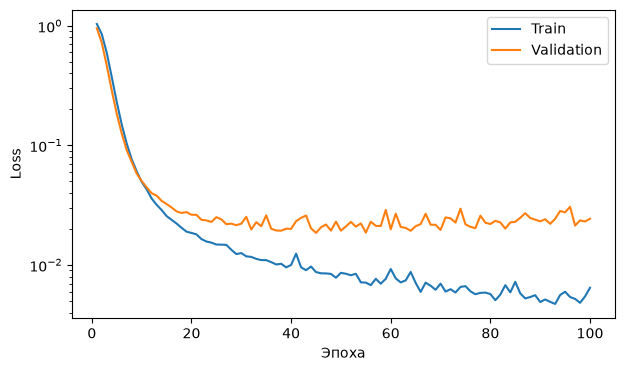

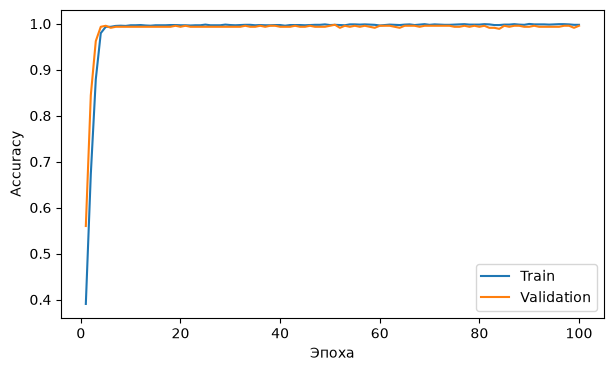

Минимальный val loss: 0.0185734527806441 эпоха 45
Максимальная val accuracy: 0.9977777777777778 первая эпоха 51


In [12]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, 101), history["train_loss"], label="Train")
plt.plot(range(1, 101), history["val_loss"], label="Validation")
plt.yscale("log")
plt.xlabel("Эпоха"); plt.ylabel("Loss"); plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(range(1, 101), history["train_acc"], label="Train")
plt.plot(range(1, 101), history["val_acc"], label="Validation")
plt.xlabel("Эпоха"); plt.ylabel("Accuracy"); plt.legend()
plt.show()

print("Минимальный val loss:", min(history["val_loss"]), "эпоха", history["best_epoch"])
print("Максимальная val accuracy:", max(history["val_acc"]),
      "первая эпоха", history["val_acc"].index(max(history["val_acc"])) + 1)

> На какой эпохе модель обучалась наиболее эффективно?

Основной прирост accuracy получен за первые 4–5 эпох: на 5-й уже 448 правильных ответов из 450 (99,56%). Дальше accuracy практически на плато. Validation loss заметно снижается примерно до 20–30-й эпохи, затем в основном колеблется около 0,02.

> Наблюдается ли переобучение?

После выхода validation loss на плато train loss продолжает снижаться, а validation loss к концу немного растёт. Это признаки слабого переобучения, но заметного ухудшения accuracy нет. Точную эпоху его начала по этим колебаниям определить нельзя.

> Совпадает ли минимальный validation loss с максимальным validation accuracy?

Формально нет: минимум loss — на эпохе 45, максимум accuracy — на эпохе 51. Но на 51-й правильно классифицировано 449 из 450 объектов, всего на один больше, чем на 5-й. Поэтому эпоха 51 — точный максимум в этом запуске, а не момент существенного улучшения качества.

> Почему эти эпохи могут различаться?

Accuracy учитывает только выбранный класс, а loss — ещё и уверенность. Поэтому loss может снижаться уже после выхода accuracy на плато. Разница в один ответ меняет accuracy на 0,22 процентного пункта: это дискретность метрики, а не ошибка округления.

In [13]:
torch.manual_seed(42)
early_model = Classifier().to(device)
optimizer = torch.optim.Adam(early_model.parameters(), lr=1e-3)
early_history = train_model(early_model, optimizer, train_loader, patience=10)
results["Early Stopping"] = early_history
print("Лучшая эпоха:", early_history["best_epoch"])

Epoch  20: train loss=0.0185, val loss=0.0263, val acc=0.9933


Epoch  40: train loss=0.0100, val loss=0.0201, val acc=0.9933


Early Stopping, эпоха 55
Лучшая эпоха: 45


> Почему для тестирования следует использовать не обязательно последнюю эпоху, а лучшую модель по validation?

Лучший checkpoint выбирается по validation loss: последняя эпоха может сильнее подогнать train и ухудшить качество на новых данных.

Пункты 25–28 с test и inference выполнены в конце, после выбора всех конфигураций.

## 29. Скрытые активации

In [14]:
activations = {}
def hook(name):
    def save(module, inputs, output):
        activations[name] = output.detach().cpu()
    return save

handles = [model.network[0].register_forward_hook(hook("Linear")),
           model.network[1].register_forward_hook(hook("ReLU"))]
model.eval()
with torch.no_grad():
    model(X_train[:64].to(device))
for handle in handles:
    handle.remove()

pd.DataFrame({name: {"mean": a.mean().item(), "std": a.std().item(),
                    "min": a.min().item(), "max": a.max().item(),
                    "доля нулей": (a == 0).float().mean().item()}
              for name, a in activations.items()}).T

,mean,std,min,max,доля нулей
Linear,0.028488,0.874302,-2.837348,2.668798,0.000000
ReLU,0.376371,0.473894,0.000000,2.668798,0.450928


> Что можно узнать о работе слоя из распределения его активаций?

Распределение показывает масштаб выходов слоя и долю обнулений ReLU. Нулевой выход на части объектов ещё не означает, что нейрон всегда неактивен.

## 30. Градиенты по слоям

{'network.0.weight': 0.025354010984301567, 'network.0.bias': 0.015798641368746758, 'network.2.weight': 0.019941195845603943, 'network.2.bias': 0.004508289508521557, 'network.4.weight': 0.026096031069755554, 'network.4.bias': 0.0028558000922203064}


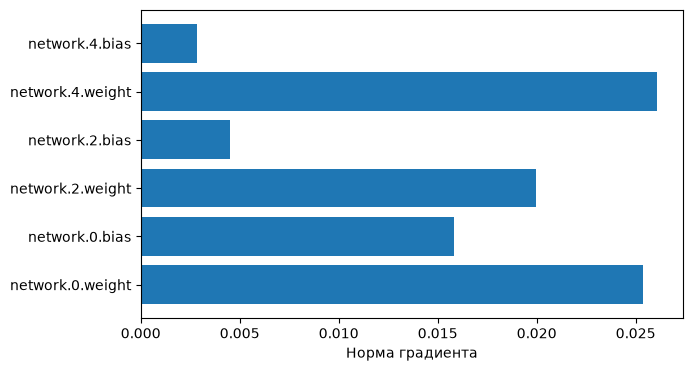

In [15]:
model.zero_grad()
loss = criterion(model(X_train[:64].to(device)), y_train[:64].to(device))
loss.backward()
gradients = {name: p.grad.norm().item() for name, p in model.named_parameters()}
print(gradients)
plt.figure(figsize=(7, 4))
plt.barh(list(gradients), list(gradients.values()))
plt.xlabel("Норма градиента")
plt.show()

> Имеются ли признаки исчезающих градиентов, чрезмерно больших градиентов, сильной разницы между слоями?

Нормы от 0,0029 до 0,0261. На этом batch не видно ни взрыва, ни сильного затухания градиентов по глубине.

## 31. ReLU, Tanh и GELU

Одинаковые начальные веса, порядок батчей, Adam, lr=0,001, batch=64 и 100 эпох.

In [16]:
for activation in [nn.Tanh, nn.GELU]:
    torch.manual_seed(42)
    candidate = Classifier(activation).to(device)
    optimizer = torch.optim.Adam(candidate.parameters(), lr=1e-3)
    name = activation.__name__
    results[name] = train_model(candidate, optimizer, train_loader)
    models[name] = candidate

activation_table = []
for name in ["ReLU", "Tanh", "GELU"]:
    h = results[name]
    h["parameters"]["activation"] = name
    activation_table.append([name, min(h["val_loss"]), max(h["val_acc"]), h["best_epoch"]])
pd.DataFrame(activation_table, columns=["Activation", "Best val loss", "Best val accuracy", "Epoch (min loss)"])

Epoch  20: train loss=0.0574, val loss=0.0621, val acc=0.9956


Epoch  40: train loss=0.0221, val loss=0.0305, val acc=0.9933


Epoch  60: train loss=0.0149, val loss=0.0226, val acc=0.9956


Epoch  80: train loss=0.0111, val loss=0.0211, val acc=0.9933


Epoch 100: train loss=0.0096, val loss=0.0219, val acc=0.9978


...

Epoch  40: train loss=0.0094, val loss=0.0245, val acc=0.9933


Epoch  60: train loss=0.0115, val loss=0.0240, val acc=0.9956


Epoch  80: train loss=0.0064, val loss=0.0275, val acc=0.9933


Epoch 100: train loss=0.0069, val loss=0.0280, val acc=0.9956


,Activation,Best val loss,Best val accuracy,Epoch (min loss)
0,ReLU,0.018573,0.997778,45
1,Tanh,0.018925,0.997778,97
2,GELU,0.022213,0.997778,32


> Есть ли существенная разница?

По лучшему val loss ReLU и Tanh близки (0,0186 и 0,0189); у GELU — 0,0222. Различия accuracy небольшие. Явного преимущества GELU здесь нет.

## 32. SGD, Adam и AdamW

Для SGD: lr=0,05, momentum=0,9. Для Adam/AdamW: lr=0,001. У AdamW оставлен стандартный weight decay=0,01.

Epoch  20: train loss=0.0145, val loss=0.0301, val acc=0.9933


Epoch  40: train loss=0.0210, val loss=0.0439, val acc=0.9911


Epoch  60: train loss=0.0232, val loss=0.0456, val acc=0.9844


Epoch  80: train loss=0.0142, val loss=0.0203, val acc=0.9978


Epoch 100: train loss=0.0189, val loss=0.0252, val acc=0.9933


Epoch  20: train loss=0.0188, val loss=0.0265, val acc=0.9933


Epoch  40: train loss=0.0102, val loss=0.0202, val acc=0.9933


Epoch  60: train loss=0.0094, val loss=0.0198, val acc=0.9956


Epoch  80: train loss=0.0060, val loss=0.0215, val acc=0.9933


Epoch 100: train loss=0.0065, val loss=0.0241, val acc=0.9956


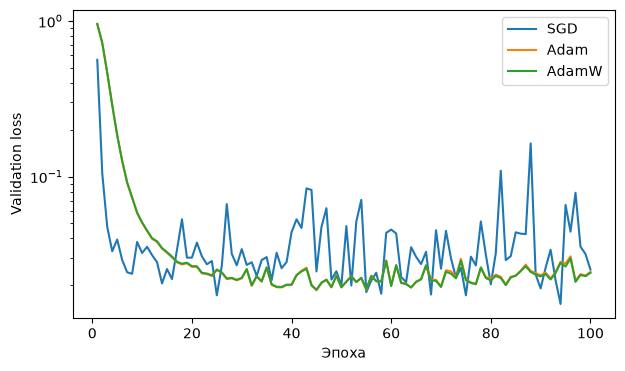

In [17]:
for name in ["SGD", "AdamW"]:
    torch.manual_seed(42)
    candidate = Classifier().to(device)
    if name == "SGD":
        optimizer = torch.optim.SGD(candidate.parameters(), lr=0.05, momentum=0.9)
    else:
        optimizer = torch.optim.AdamW(candidate.parameters(), lr=1e-3)
    results[name] = train_model(candidate, optimizer, train_loader)
    models[name] = candidate

plt.figure(figsize=(7, 4))
for label, name in [("SGD", "SGD"), ("Adam", "ReLU"), ("AdamW", "AdamW")]:
    plt.plot(range(1, 101), results[name]["val_loss"], label=label)
plt.yscale("log")
plt.xlabel("Эпоха"); plt.ylabel("Validation loss"); plt.legend()
plt.show()

SGD быстро снижает loss, но сильнее колеблется; его минимум — 0,0152. Adam и AdamW дают похожие кривые и минимумы около 0,0186–0,0187.

## 33. Размер batch

In [18]:
batch_rows = []
for batch_size in [8, 32, 128, 512]:
    torch.manual_seed(42)
    candidate = Classifier().to(device)
    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(42))
    optimizer = torch.optim.Adam(candidate.parameters(), lr=1e-3)
    name = f"batch={batch_size}"
    h = train_model(candidate, optimizer, loader)
    results[name], models[name] = h, candidate
    batch_rows.append([batch_size, sum(h["time"]) / len(h["time"]), h["val_loss"][-1], h["val_acc"][-1]])

pd.DataFrame(batch_rows, columns=["Batch", "Время эпохи, с", "Последний val loss", "Последняя val accuracy"])

Epoch  20: train loss=0.0162, val loss=0.0245, val acc=0.9933


Epoch  40: train loss=0.0101, val loss=0.0247, val acc=0.9933


Epoch  60: train loss=0.0048, val loss=0.0209, val acc=0.9933


Epoch  80: train loss=0.0075, val loss=0.0323, val acc=0.9956


Epoch 100: train loss=0.0056, val loss=0.0274, val acc=0.9956


...

Epoch  80: train loss=0.0083, val loss=0.0239, val acc=0.9933
Epoch 100: train loss=0.0074, val loss=0.0213, val acc=0.9933


Epoch  20: train loss=0.3730, val loss=0.3489, val acc=0.9867
Epoch  40: train loss=0.0858, val loss=0.0872, val acc=0.9933


Epoch  60: train loss=0.0395, val loss=0.0457, val acc=0.9933
Epoch  80: train loss=0.0245, val loss=0.0319, val acc=0.9933


Epoch 100: train loss=0.0185, val loss=0.0285, val acc=0.9933


,Batch,"Время эпохи, с",Последний val loss,Последняя val accuracy
0,8,0.089636,0.027366,0.995556
1,32,0.026765,0.028167,0.995556
2,128,0.008714,0.021271,0.993333
3,512,0.005473,0.028478,0.993333


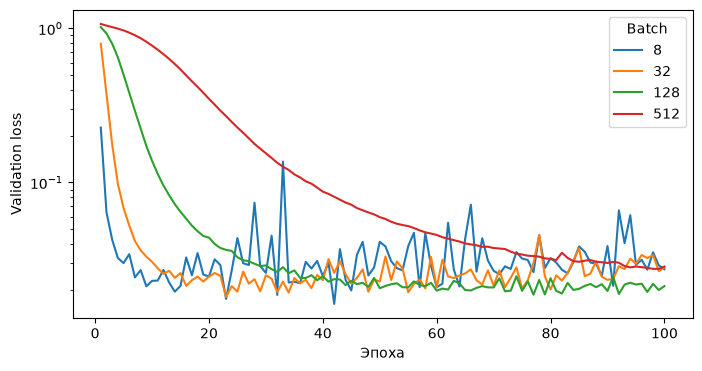

In [19]:
plt.figure(figsize=(8, 4))
for batch_size in [8, 32, 128, 512]:
    plt.plot(range(1, 101), results[f"batch={batch_size}"]["val_loss"], label=str(batch_size))
plt.yscale("log")
plt.xlabel("Эпоха"); plt.ylabel("Validation loss"); plt.legend(title="Batch")
plt.show()

При batch=8 кривая заметно шумнее, эпоха занимает около 0,090 с; при 512 — 0,005 с. Большой batch делает меньше обновлений за эпоху и сходится медленнее по числу эпох. Время в таблице включает обучение и validation.

> Почему маленький batch обычно создаёт более шумную траекторию оптимизации?

Малый batch даёт более шумную оценку градиента.

## 34. Learning rate = 1,0

In [20]:
torch.manual_seed(42)
bad_model = Classifier().to(device)
optimizer = torch.optim.Adam(bad_model.parameters(), lr=1.)
train_loader.generator.manual_seed(42)
bad_rows = []
for epoch in range(10):
    train_loss, train_acc = train_epoch(bad_model, train_loader, criterion, optimizer, device)
    # Градиенты последнего batch, вычисленные перед его обновлением.
    grad_norm = sum(p.grad.norm().item() ** 2 for p in bad_model.parameters()) ** 0.5
    val_loss, val_acc = evaluate(bad_model, val_loader, criterion, device)
    bad_rows.append([epoch + 1, train_loss, val_loss, val_acc, grad_norm])
pd.DataFrame(bad_rows, columns=["Эпоха", "Train loss", "Val loss", "Val accuracy", "Gradient norm"])

,Эпоха,Train loss,Val loss,Val accuracy,Gradient norm
0,1,27.185113,0.787557,0.720000,0.632501
1,2,0.914018,0.908402,0.555556,0.483244
2,3,0.918047,1.342283,0.455556,0.489741
3,4,0.967927,0.912633,0.484444,0.165134
4,5,0.908616,0.924213,0.468889,0.146627
5,6,0.906367,0.911200,0.484444,0.100976
6,7,0.874863,0.882500,0.522222,0.315572
7,8,0.863191,0.841277,0.533333,0.302686
8,9,0.845244,0.807044,0.571111,0.240579
9,10,3.012500,1.016201,0.448889,0.346529


> Что произошло?

При lr=1 обучение нестабильно: первая train loss около 27,2, итоговая validation accuracy — 44,9%.

> Почему слишком большой learning rate может приводить к нестабильному обучению?

Слишком крупные шаги перескакивают область минимума; конечные значения градиентов сами по себе не означают хорошую сходимость.

## 35. Переобучение

Сеть 2 → 256 → 256 → 256 → 3, 200 объектов train, 400 эпох без ранней остановки.

Epoch  20: train loss=0.0177, val loss=0.0434, val acc=0.9867
Epoch  40: train loss=0.0031, val loss=0.0278, val acc=0.9911


Epoch  60: train loss=0.0015, val loss=0.0291, val acc=0.9911
Epoch  80: train loss=0.0011, val loss=0.0301, val acc=0.9933


Epoch 100: train loss=0.0005, val loss=0.0267, val acc=0.9911
Epoch 120: train loss=0.0004, val loss=0.0252, val acc=0.9933


Epoch 140: train loss=0.0003, val loss=0.0283, val acc=0.9911
Epoch 160: train loss=0.0002, val loss=0.0286, val acc=0.9911


Epoch 180: train loss=0.0006, val loss=0.0271, val acc=0.9911
Epoch 200: train loss=0.0002, val loss=0.0299, val acc=0.9911


Epoch 220: train loss=0.0001, val loss=0.0293, val acc=0.9911
Epoch 240: train loss=0.0001, val loss=0.0288, val acc=0.9911
Epoch 260: train loss=0.0001, val loss=0.0298, val acc=0.9911


Epoch 280: train loss=0.0001, val loss=0.0292, val acc=0.9911
Epoch 300: train loss=0.0001, val loss=0.0309, val acc=0.9911
Epoch 320: train loss=0.0001, val loss=0.0314, val acc=0.9911


Epoch 340: train loss=0.0001, val loss=0.0314, val acc=0.9911
Epoch 360: train loss=0.0000, val loss=0.0326, val acc=0.9911
Epoch 380: train loss=0.0000, val loss=0.0344, val acc=0.9889


Epoch 400: train loss=0.0000, val loss=0.0356, val acc=0.9889


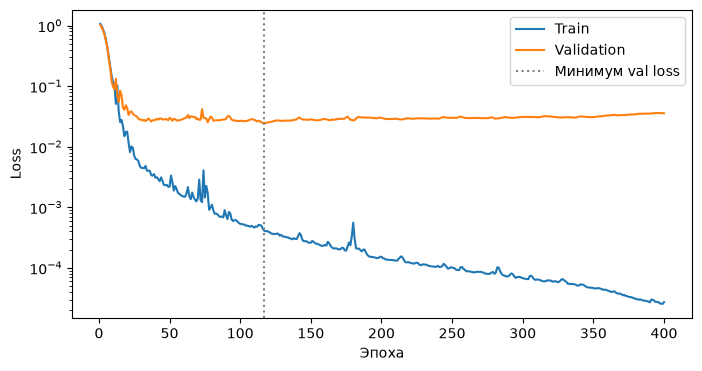

In [21]:
torch.manual_seed(42)
large_model = Classifier().to(device)
large_model.network = nn.Sequential(
    nn.Linear(2, 256), nn.ReLU(),
    nn.Linear(256, 256), nn.ReLU(),
    nn.Linear(256, 256), nn.ReLU(),
    nn.Linear(256, 3)
).to(device)
small_loader = DataLoader(ClassificationDataset(X_train[:200], y_train[:200]),
                          batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(42))
optimizer = torch.optim.Adam(large_model.parameters(), lr=1e-3)
overfit = train_model(large_model, optimizer, small_loader, epochs=400)
results["overfit"] = overfit

plt.figure(figsize=(8, 4))
plt.plot(range(1, 401), overfit["train_loss"], label="Train")
plt.plot(range(1, 401), overfit["val_loss"], label="Validation")
plt.axvline(overfit["best_epoch"], color="gray", linestyle=":", label="Минимум val loss")
plt.yscale("log")
plt.xlabel("Эпоха"); plt.ylabel("Loss"); plt.legend()
plt.show()

Минимум val loss достигнут на эпохе 117 (0,0246). Дальше train loss падает почти до нуля, а val loss к концу растёт до 0,0356.

> Почему уменьшение train loss после этого момента уже нельзя считать улучшением модели?

Это переобучение: ошибка на знакомых точках падает, а на новых растёт.

## 36. Выбор модели

Выбираю по минимальному validation loss, при равенстве — по accuracy. Диагностические опыты с lr=1 и малым train не участвуют.

In [22]:
comparison = []
for name in models:
    h = results[name]
    comparison.append([name, min(h["val_loss"]), h["val_accuracy"], h["best_epoch"]])
comparison = pd.DataFrame(comparison, columns=["Модель", "Val loss", "Val accuracy", "Эпоха"])
comparison = comparison.sort_values(["Val loss", "Val accuracy"], ascending=[True, False])
best_name = comparison.iloc[0]["Модель"]
best_model = models[best_name]
print("Выбрана модель:", best_name)
comparison

Выбрана модель: SGD


,Модель,Val loss,Val accuracy,Эпоха
3,SGD,0.015171,0.997778,94
5,batch=8,0.016289,0.993333,42
6,batch=32,0.018105,0.991111,23
0,ReLU,0.018573,0.993333,45
7,batch=128,0.018700,0.993333,77
4,AdamW,0.018733,0.993333,45
1,Tanh,0.018925,0.993333,97
2,GELU,0.022213,0.995556,32
8,batch=512,0.027510,0.993333,99


## 38. Вариант 12: BatchNorm

Проверю, ускоряет ли BatchNorm сходимость и делает ли обучение устойчивее. Сравню базовую сеть с такой же сетью, добавив BatchNorm перед каждой ReLU. Остальные настройки одинаковы.

Epoch  20: train loss=0.1892, val loss=0.0665, val acc=0.9911


Epoch  40: train loss=0.1793, val loss=0.0451, val acc=0.9933


Epoch  60: train loss=0.1517, val loss=0.0464, val acc=0.9911


Epoch  80: train loss=0.1784, val loss=0.0481, val acc=0.9867


Epoch 100: train loss=0.1640, val loss=0.0385, val acc=0.9933


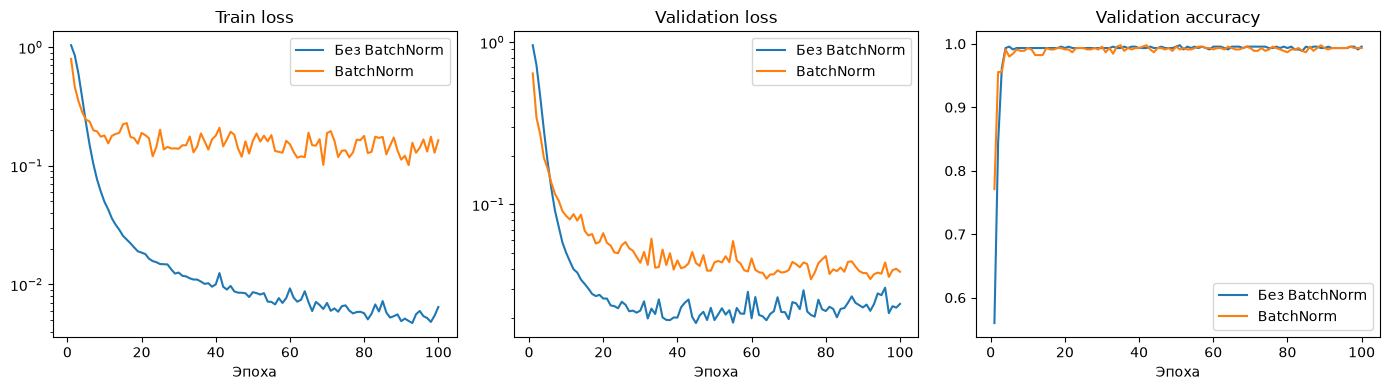

In [23]:
class BatchNormClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# Без BatchNorm уже обучена базовая модель ReLU.
plain_model = models["ReLU"]
torch.manual_seed(42)
bn_model = BatchNormClassifier().to(device)
optimizer = torch.optim.Adam(bn_model.parameters(), lr=1e-3)
bn_history = train_model(bn_model, optimizer, train_loader, filename="with_bn.pt")
results["BatchNorm"] = bn_history

variant_models = {"Без BatchNorm": plain_model, "BatchNorm": bn_model}
variant_histories = {"Без BatchNorm": results["ReLU"], "BatchNorm": bn_history}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for name, h in variant_histories.items():
    axes[0].plot(range(1, 101), h["train_loss"], label=name)
    axes[1].plot(range(1, 101), h["val_loss"], label=name)
    axes[2].plot(range(1, 101), h["val_acc"], label=name)
for ax, title in zip(axes, ["Train loss", "Validation loss", "Validation accuracy"]):
    ax.set_title(title); ax.set_xlabel("Эпоха"); ax.legend()
axes[0].set_yscale("log"); axes[1].set_yscale("log")
plt.tight_layout()
plt.show()

Число эпох до val loss ≤ 0,1 характеризует сходимость. Колебания оцениваю по std приращений val loss на последних 20 эпохах.

In [24]:
variant_rows = []
for name, h in variant_histories.items():
    threshold_epoch = next((i + 1 for i, loss in enumerate(h["val_loss"]) if loss <= 0.1), None)
    tail = torch.tensor(h["val_loss"][-20:])
    fluctuation = (tail[1:] - tail[:-1]).std().item()
    variant_rows.append([name, min(h["val_loss"]), h["val_accuracy"], threshold_epoch,
                         sum(h["time"]) / 100, fluctuation])
variant_table = pd.DataFrame(variant_rows, columns=["Модель", "Best val loss", "Val accuracy",
                                                   "Эпоха loss ≤ 0.1", "Время эпохи, с", "Колебания loss"])
variant_table

,Модель,Best val loss,Val accuracy,Эпоха loss ≤ 0.1,"Время эпохи, с",Колебания loss
0,Без BatchNorm,0.018573,0.993333,7,0.014688,0.002968
1,BatchNorm,0.034569,0.995556,9,0.036876,0.003401


### Распределение активаций

Один train-batch, обе модели в eval. Снимаю вход второй ReLU: после Linear в обычной сети, после BatchNorm в другой.

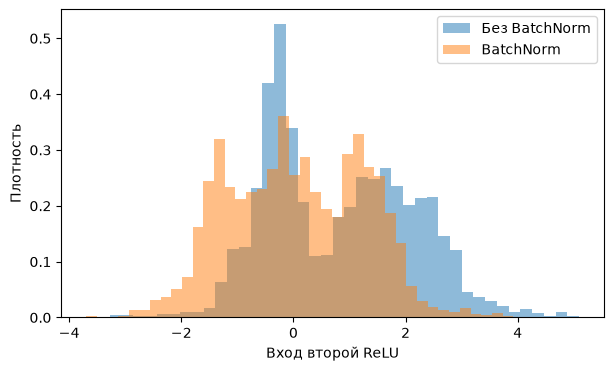

,mean,std
Без BatchNorm,0.824187,1.307908
BatchNorm,0.067667,1.204631


In [25]:
activations = {}
handles = [plain_model.network[2].register_forward_hook(hook("Без BatchNorm")),
           bn_model.network[4].register_forward_hook(hook("BatchNorm"))]
for model in variant_models.values():
    model.eval()
    with torch.no_grad():
        model(X_train[:64].to(device))
for handle in handles:
    handle.remove()

plt.figure(figsize=(7, 4))
for name, values in activations.items():
    plt.hist(values.flatten().numpy(), bins=40, density=True, alpha=0.5, label=name)
plt.xlabel("Вход второй ReLU"); plt.ylabel("Плотность"); plt.legend()
plt.show()
pd.DataFrame({name: {"mean": a.mean().item(), "std": a.std().item()}
              for name, a in activations.items()}).T

> Дополнительно объяснить различие поведения BatchNorm в режимах model.train() и model.eval().

В `train()` BatchNorm использует среднее и дисперсию текущего batch и обновляет накопленные статистики. В `eval()` берёт накопленные значения. `no_grad()` само по себе режим не переключает.

После обучения выход BatchNorm не обязан иметь точно нулевое среднее и единичную дисперсию: γ и β обучаются, а статистики batch отличаются от накопленных.

## 25–28. Test, матрица ошибок, границы и inference

Конфигурации выбраны. Теперь проверяю итоговую модель основной части и две модели варианта 12; параметры после test не меняю.

In [26]:
final_models = {"Основная часть": best_model, **variant_models}
test_results = {}
confusions = {}
for name, model in final_models.items():
    model.eval()
    total_loss = 0
    predictions = []
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb.to(device))
            total_loss += criterion(logits, yb.to(device)).item() * len(yb)
            predictions.append(logits.argmax(1).cpu())
    pred = torch.cat(predictions)
    confusion = torch.zeros(3, 3, dtype=torch.long)
    for actual, predicted in zip(y_test, pred):
        confusion[actual, predicted] += 1
    confusions[name] = confusion
    test_results[name] = {"Test loss": total_loss / len(y_test),
                          "Test accuracy": (pred == y_test).float().mean().item()}

pd.DataFrame(test_results).T

,Test loss,Test accuracy
Основная часть,0.011223,0.993333
Без BatchNorm,0.010834,0.995556
BatchNorm,0.026697,0.991111


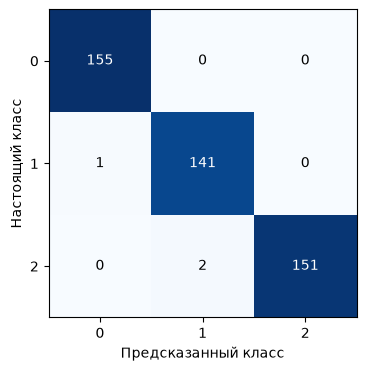

In [27]:
confusion = confusions["Основная часть"]
plt.figure(figsize=(4, 4))
plt.imshow(confusion, cmap="Blues")
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(confusion[i, j].item()), ha="center", va="center",
                 color="white" if confusion[i, j] > confusion.max() / 2 else "black")
plt.xticks([0, 1, 2]); plt.yticks([0, 1, 2])
plt.xlabel("Предсказанный класс"); plt.ylabel("Настоящий класс")
plt.show()

Ошибок 3 из 450. Все ошибки — между соседними по радиусу классами.

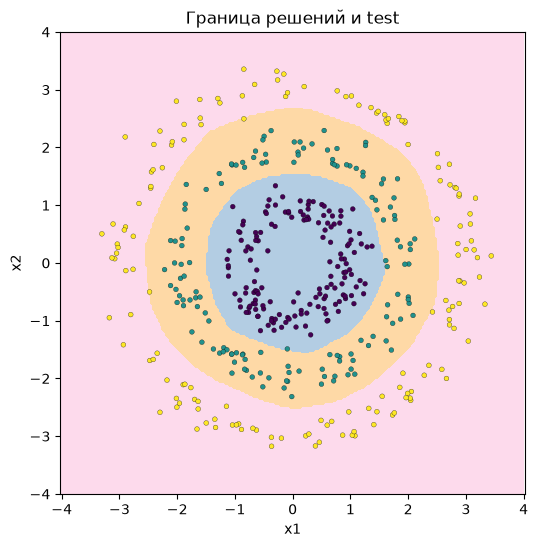

In [28]:
axis = torch.linspace(-4, 4, 250)
gx, gy = torch.meshgrid(axis, axis, indexing="xy")
grid = torch.stack([gx.flatten(), gy.flatten()], dim=1)
best_model.eval()
with torch.inference_mode():
    labels = best_model(((grid - mean) / std).to(device)).argmax(1).cpu().reshape(gx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(gx, gy, labels, levels=[-0.5, 0.5, 1.5, 2.5], cmap="Pastel1")
plt.scatter(X[test_idx, 0], X[test_idx, 1], c=y_test, s=12, edgecolors="black", linewidths=0.2)
plt.xlabel("x1"); plt.ylabel("x2"); plt.title("Граница решений и test")
plt.axis("equal")
plt.show()

Границы получились замкнутыми и разделяют кольца. Сетку нормализовал теми же mean и std, что и train.

In [29]:
new_data = torch.tensor([[0.8, 0.2], [1.7, 0.8], [2.8, -0.5]], dtype=torch.float32)
for name, model in final_models.items():
    model.eval()
    with torch.inference_mode():
        probabilities = model(((new_data - mean) / std).to(device)).softmax(dim=1).cpu()
    print(name)
    print(probabilities)
    print("Классы:", probabilities.argmax(1).tolist())

Основная часть
tensor([[1.0000e+00, 2.4830e-06, 4.3590e-29],
        [2.7470e-06, 1.0000e+00, 3.5856e-12],
        [6.3182e-31, 7.1777e-06, 9.9999e-01]])
Классы: [0, 1, 2]
Без BatchNorm
tensor([[9.9998e-01, 1.9100e-05, 1.5090e-13],
        [6.7167e-04, 9.9932e-01, 1.0153e-05],
        [3.7838e-15, 5.2592e-04, 9.9947e-01]])
Классы: [0, 1, 2]
BatchNorm
tensor([[9.9987e-01, 1.2841e-04, 9.5434e-08],
        [3.5112e-02, 9.6066e-01, 4.2238e-03],
        [7.4980e-06, 1.0840e-02, 9.8915e-01]])
Классы: [0, 1, 2]


По радиусам новых точек ожидаются классы 0, 1 и 2.

## 37. Итоговая таблица

In [30]:
h = results[best_name]
activation = best_name if best_name in ["ReLU", "Tanh", "GELU"] else "ReLU"
pd.DataFrame({"Параметр": ["Архитектура", "Activation", "Optimizer", "Learning rate", "Batch size",
                          "Epochs", "Early stopping", "Лучшая эпоха", "Best validation loss",
                          "Validation accuracy", "Test accuracy", "Число параметров", "Device"],
              "Значение": ["2 → 64 → 64 → 3", activation, h["parameters"]["optimizer"], h["parameters"]["lr"],
                           h["parameters"]["batch_size"], len(h["train_loss"]), "Нет (100 эпох)", h["best_epoch"],
                           min(h["val_loss"]), h["val_accuracy"], test_results["Основная часть"]["Test accuracy"],
                           sum(p.numel() for p in best_model.parameters()), str(device)]})

,Параметр,Значение
0,Архитектура,2 → 64 → 64 → 3
1,Activation,ReLU
2,Optimizer,SGD
3,Learning rate,0.05
4,Batch size,64
5,Epochs,100
6,Early stopping,Нет (100 эпох)
7,Лучшая эпоха,94
8,Best validation loss,0.015171
9,Validation accuracy,0.997778


### Сохранение результатов

In [31]:
for filename, model in [("best_model.pt", best_model), ("without_bn.pt", plain_model), ("with_bn.pt", bn_model)]:
    torch.save({"state_dict": model.state_dict(), "mean": mean, "std": std}, filename)
results["test"] = test_results
results["selected_model"] = best_name
torch.save(results, "results.pt")

## Вывод по индивидуальному варианту

> Какая гипотеза исследовалась?

BatchNorm ускорит и стабилизирует обучение.

> Какие конфигурации сравнивались?

Сети 2 → 64 → 64 → 3 с ReLU, с BatchNorm и без него; Adam, lr=0,001, batch=64, 100 эпох.

> Какой результат оказался лучшим?

По val loss лучше сеть без BatchNorm: 0,0186 против 0,0346. При этом validation accuracy у BatchNorm немного выше: 99,56% против 99,33%; test accuracy — 99,11% и 99,56% соответственно. Критерии loss и accuracy учитывают разные свойства предсказаний.

> Почему он оказался лучше остальных?

BatchNorm меняет масштаб активаций, но статистики небольших батчей добавляют шум. Для простой задачи с уже нормализованным входом это не дало выигрыша по loss. Среднее входов второй ReLU у сети с BatchNorm — 0,07, без него — 0,82.

> Какие признаки переобучения или нестабильности наблюдались?

У обычной сети после лучшей эпохи заметен рост validation loss при снижении train loss. Колебания val loss немного сильнее с BatchNorm: 0,0034 против 0,0030. У BatchNorm train loss выше validation: в этих режимах используются разные статистики.

> Насколько результаты соответствуют первоначальной гипотезе?

Гипотеза в этом запуске не подтвердилась: без BatchNorm loss ≤ 0,1 достигнут на 7-й эпохе, с ним — на 9-й. Вывод относится к одному запуску, а не ко всем задачам.